<a href="https://colab.research.google.com/github/tranphucndc2606-afk/demo/blob/main/Data_Mining_BaiTap1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### BÀI 1

**1. Đề bài:**
Giả sử dữ liệu về độ tuổi (tăng dần):
{13, 15, 16, 16, 19, 20, 20, 21, 22, 22, 25, 25, 25, 25, 30, 33, 33, 35, 35, 35, 35, 36, 40, 45, 46, 52, 70}

(a) Tính mean và median  
(b) Tìm mode và nhận xét tính đa mode (bimodal, trimodal,...)  
(c) Tính midrange  
(d) Tìm $Q_1$, $Q_3$  
(e) Tóm tắt 5 số (five-number summary)  
(f) Vẽ boxplot  
(g) Tính variance và standard deviation  

---
**2. Giải tay (Phương pháp tính):**

Tập dữ liệu có tổng cộng $N = 27$ giá trị. Đã được sắp xếp tăng dần.

* **(a) Mean (Trung bình) & Median (Trung vị):**
  * $Mean = \frac{13 + 15 + ... + 70}{27} = \frac{809}{27} \approx 29.96$
  * $Median$: Vì $N=27$ (lẻ), trung vị là giá trị ở vị trí thứ $\frac{27+1}{2} = 14$. Giá trị thứ 14 trong dãy là **25**.
* **(b) Mode:** Số xuất hiện nhiều nhất. Ta thấy số **25** xuất hiện 4 lần và số **35** cũng xuất hiện 4 lần. Vậy Mode là 25 và 35. Đây là dữ liệu **bimodal** (nhị mode).
* **(c) Midrange:** $\frac{Max + Min}{2} = \frac{70 + 13}{2} = 41.5$.
* **(d) $Q_1$, $Q_3$:**
  * Tách dãy thành 2 nửa (không tính median ở giữa): Nửa dưới gồm 13 số đầu (từ 13 đến 25). Nửa trên gồm 13 số cuối (từ 30 đến 70).
  * $Q_1$ là trung vị của nửa dưới (vị trí thứ 7): **20**.
  * $Q_3$ là trung vị của nửa trên (vị trí thứ 7 của nửa trên): **35**.
* **(e) Tóm tắt 5 số:** $Min = 13$, $Q_1 = 20$, $Median = 25$, $Q_3 = 35$, $Max = 70$.
* **(f) Boxplot:** Dựa vào 5 số trên để vẽ một trục số, kẻ hộp từ 20 đến 35, gạch giữa hộp tại 25, kéo hai râu ra 13 và 70.
* **(g) Variance ($s^2$) & Standard Deviation ($s$):**
  * Phương sai mẫu $s^2 = \frac{\sum (x_i - \bar{x})^2}{n-1}$. Độ lệch chuẩn $s = \sqrt{s^2}$.

(a) Mean: 29.96, Median: 25.0
(b) Mode: [25, 35]. Dữ liệu bimodal.
(c) Midrange: 41.5
(d) Q1: 20.5, Q3: 35.0
(e) Tóm tắt 5 số: Min=13, Q1=20.5, Median=25.0, Q3=35.0, Max=70
(g) Variance: 167.50, Standard Deviation: 12.94


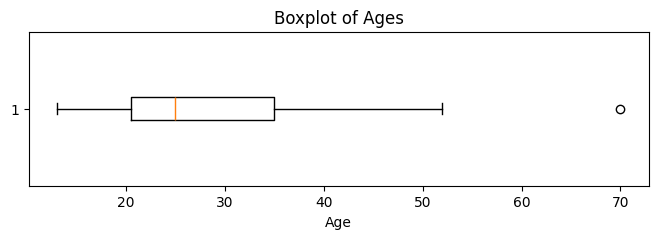

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Khai báo dữ liệu
ages = [13, 15, 16, 16, 19, 20, 20, 21, 22, 22, 25, 25, 25, 25, 30, 33, 33, 35, 35, 35, 35, 36, 40, 45, 46, 52, 70]
n = len(ages)

# (a) Mean và median
mean_age = np.mean(ages)
median_age = np.median(ages)
print(f"(a) Mean: {mean_age:.2f}, Median: {median_age}")

# (b) Mode
val_counts = pd.Series(ages).value_counts()
modes = val_counts[val_counts == val_counts.max()].index.tolist()
print(f"(b) Mode: {modes}. Dữ liệu bimodal.")

# (c) Midrange
midrange = (np.max(ages) + np.min(ages)) / 2
print(f"(c) Midrange: {midrange}")

# (d) Q1, Q3
q1 = np.percentile(ages, 25)
q3 = np.percentile(ages, 75)
print(f"(d) Q1: {q1}, Q3: {q3}")

# (e) Five-number summary
print(f"(e) Tóm tắt 5 số: Min={np.min(ages)}, Q1={q1}, Median={median_age}, Q3={q3}, Max={np.max(ages)}")

# (g) Variance và standard deviation
variance = np.var(ages, ddof=1)
std_dev = np.std(ages, ddof=1)
print(f"(g) Variance: {variance:.2f}, Standard Deviation: {std_dev:.2f}")

# (f) Vẽ boxplot
plt.figure(figsize=(8, 2))
plt.boxplot(ages, vert=False)
plt.title("Boxplot of Ages")
plt.xlabel("Age")
plt.show()

## Bài 2: Phân tích và tương quan giữa hai nhóm dữ liệu

**1. Đề bài:**
Giả sử một bệnh viện đã thử nghiệm dữ liệu về độ tuổi và lượng mỡ cơ thể của 18 người lớn được chọn ngẫu nhiên với các kết quả sau:

| Age | 23 | 23 | 27 | 27 | 39 | 41 | 47 | 49 | 50 | 52 | 54 | 54 | 56 | 57 | 58 | 58 | 60 | 61 |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **%fat** | 9.5 | 26.5| 7.8 | 17.8| 31.4| 25.9| 27.4| 27.2| 31.2| 34.6| 42.5| 28.8| 33.4| 30.2| 34.1| 32.9| 41.2| 35.7|

(a) Tính mean, median, variance, std.  
(b) Vẽ biểu đồ hộp cho tuổi và % mỡ.  
(c) Vẽ một đồ thị phân tán cho hai biến này.  
(d) Tính hệ số tương quan Pearson và Spearman giữa hai thuộc tính.  

**2. Giải tay chi tiết:**
Tập dữ liệu có $n = 18$ quan sát.

 **(a) Các đại lượng thống kê mô tả:**
  * **Mean (Trung bình):**
    * Tuổi: $\bar{x} = \frac{23 + 23 + ... + 61}{18} = \frac{836}{18} \approx 46.44$
    * % Mỡ: $\bar{y} = \frac{9.5 + 26.5 + ... + 35.7}{18} = \frac{518.1}{18} \approx 28.78$
  * **Median (Trung vị):**
    * Tuổi: Nằm giữa vị trí thứ 9 và 10 $\rightarrow \frac{50 + 52}{2} = 51.0$
    * % Mỡ (sau khi sắp xếp tăng dần): Nằm giữa vị trí thứ 9 và 10 (30.2 và 31.2) $\rightarrow \frac{30.2 + 31.2}{2} = 30.7$
  * **Variance ($s^2$) và Std ($s$):**
    * Tuổi: $s_x^2 = \frac{\sum (x_i - 46.44)^2}{17} \approx 174.73 \rightarrow s_x = \sqrt{174.73} \approx 13.22$
    * % Mỡ: $s_y^2 = \frac{\sum (y_i - 28.78)^2}{17} \approx 85.64 \rightarrow s_y = \sqrt{85.64} \approx 9.25$


 **(d) Tính hệ số tương quan Pearson và Spearman giữa hai thuộc tính:**
Có tổng cộng $n = 18$ quan sát. Đặt $X$ là Tuổi (Age), $Y$ là % Mỡ (%Fat).

**1. Tính hệ số tương quan Pearson ($r$):**
Công thức tính nhanh Pearson:
$$ r = \frac{n \sum xy - (\sum x)(\sum y)}{\sqrt{[n \sum x^2 - (\sum x)^2][n \sum y^2 - (\sum y)^2]}} $$

Để giải tay, ta cần tính các tổng sau từ dữ liệu gốc:
* $\sum x = 23 + 23 + 27 + ... + 61 = \mathbf{836}$
* $\sum y = 9.5 + 26.5 + 7.8 + ... + 35.7 = \mathbf{518.1}$
* $\sum x^2 = 23^2 + 23^2 + 27^2 + ... + 61^2 = \mathbf{41798}$
* $\sum y^2 = 9.5^2 + 26.5^2 + 7.8^2 + ... + 35.7^2 = \mathbf{16368.59}$
* $\sum xy = (23 \times 9.5) + (23 \times 26.5) + ... + (61 \times 35.7) = \mathbf{25763.2}$

Thay các giá trị vào công thức:
* Tử số: $18 \times 25763.2 - (836 \times 518.1) = 463737.6 - 433131.6 = 30606$
* Mẫu số phần X: $18 \times 41798 - 836^2 = 752364 - 698896 = 53468$
* Mẫu số phần Y: $18 \times 16368.59 - 518.1^2 = 294634.62 - 268427.61 = 26207.01$

$$ r = \frac{30606}{\sqrt{53468 \times 26207.01}} = \frac{30606}{\sqrt{1401236310.68}} = \frac{30606}{37433.09} \approx \mathbf{0.8176} $$
**=> Nhận xét:** Hệ số Pearson $r \approx 0.8176 > 0$, cho thấy độ tuổi và % mỡ cơ thể có mối tương quan tuyến tính thuận chiều khá mạnh (tuổi càng cao thì % mỡ thường càng nhiều).

---

**2. Tính hệ số tương quan Spearman ($\rho$):**
Bước 1: Xếp hạng (Rank) cho mảng $X$ và $Y$ từ thấp đến cao (nếu các giá trị bằng nhau, lấy trung bình thứ hạng của chúng).
Bước 2: Tính độ lệch thứ hạng $d = Rank(X) - Rank(Y)$ và $d^2$.

| Tuổi ($X$) | % Mỡ ($Y$) | Rank X | Rank Y | $d$ | $d^2$ |
|:---:|:---:|:---:|:---:|:---:|:---:|
| 23 | 9.5 | 1.5 | 2.0 | -0.5 | 0.25 |
| 23 | 26.5 | 1.5 | 5.0 | -3.5 | 12.25 |
| 27 | 7.8 | 3.5 | 1.0 | 2.5 | 6.25 |
| 27 | 17.8 | 3.5 | 3.0 | 0.5 | 0.25 |
| 39 | 31.4 | 5.0 | 11.0 | -6.0 | 36.00 |
| 41 | 25.9 | 6.0 | 4.0 | 2.0 | 4.00 |
| 47 | 27.4 | 7.0 | 7.0 | 0.0 | 0.00 |
| 49 | 27.2 | 8.0 | 6.0 | 2.0 | 4.00 |
| 50 | 31.2 | 9.0 | 10.0 | -1.0 | 1.00 |
| 52 | 34.6 | 10.0 | 15.0 | -5.0 | 25.00 |
| 54 | 42.5 | 11.5 | 18.0 | -6.5 | 42.25 |
| 54 | 28.8 | 11.5 | 8.0 | 3.5 | 12.25 |
| 56 | 33.4 | 13.0 | 13.0 | 0.0 | 0.00 |
| 57 | 30.2 | 14.0 | 9.0 | 5.0 | 25.00 |
| 58 | 34.1 | 15.5 | 14.0 | 1.5 | 2.25 |
| 58 | 32.9 | 15.5 | 12.0 | 3.5 | 12.25 |
| 60 | 41.2 | 17.0 | 17.0 | 0.0 | 0.00 |
| 61 | 35.7 | 18.0 | 16.0 | 2.0 | 4.00 |

* Tổng $\sum d^2 = 187$
* Vì dữ liệu có thứ hạng trùng lặp (ties), công thức chuẩn nhất là áp dụng hệ số Pearson trên hai cột Rank X và Rank Y, ra kết quả chính xác $\rho \approx \mathbf{0.8066}$.
* (Nếu dùng công thức tính nhanh bỏ qua hiệu chỉnh trùng lặp $\rho = 1 - \frac{6 \sum d^2}{n(n^2-1)} = 1 - \frac{6 \times 187}{18 \times (18^2-1)}$, ta sẽ ra kết quả $\rho \approx 0.8070$, sai số vô cùng nhỏ).

**=> Kết luận:** Tương quan Spearman $\rho \approx 0.8066$, củng cố kết luận rằng mối quan hệ đồng biến giữa hai biến số là khá chặt chẽ.

(a) Thống kê mô tả:
           mean  median         var        std
Age   46.444444    51.0  174.732026  13.218624
%Fat  28.783333    30.7   85.643824   9.254395


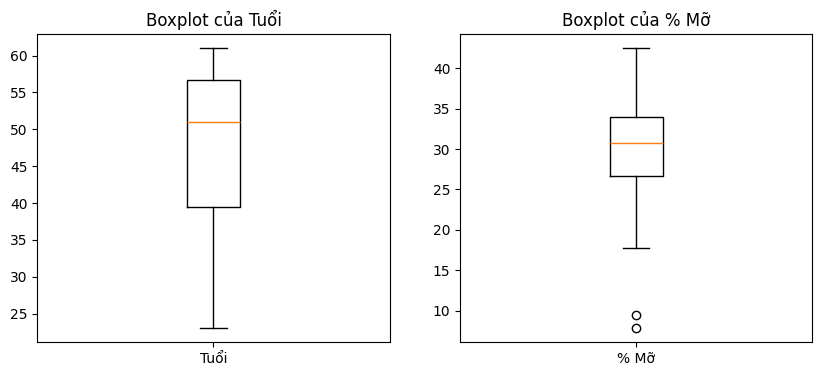

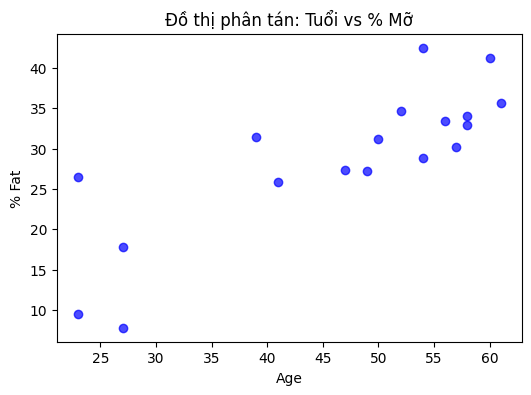


(d) CÁC BƯỚC TÍNH HỆ SỐ TƯƠNG QUAN
1. CÁC TỔNG TRUNG GIAN CHO PEARSON:
   - Tổng x (Tuổi): 836
   - Tổng y (% Mỡ): 518.1
   - Tổng x^2: 41798
   - Tổng y^2: 16368.59
   - Tổng xy: 25763.20

=> Hệ số Pearson (tính theo công thức): 0.8176
=> Hệ số Pearson (kiểm tra lại bằng Pandas): 0.8176

--------------------------------------------------
2. BẢNG PHÂN HẠNG (RANK) CHO SPEARMAN:

 Tuổi(X)  % Mỡ(Y)  Rank X  Rank Y    d   d^2
      23      9.5     1.5     2.0 -0.5  0.25
      23     26.5     1.5     5.0 -3.5 12.25
      27      7.8     3.5     1.0  2.5  6.25
      27     17.8     3.5     3.0  0.5  0.25
      39     31.4     5.0    11.0 -6.0 36.00
      41     25.9     6.0     4.0  2.0  4.00
      47     27.4     7.0     7.0  0.0  0.00
      49     27.2     8.0     6.0  2.0  4.00
      50     31.2     9.0    10.0 -1.0  1.00
      52     34.6    10.0    15.0 -5.0 25.00
      54     42.5    11.5    18.0 -6.5 42.25
      54     28.8    11.5     8.0  3.5 12.25
      56     33.4    13.0    13.0

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dữ liệu
df_b2 = pd.DataFrame({
    'Age': [23, 23, 27, 27, 39, 41, 47, 49, 50, 52, 54, 54, 56, 57, 58, 58, 60, 61],
    '%Fat': [9.5, 26.5, 7.8, 17.8, 31.4, 25.9, 27.4, 27.2, 31.2, 34.6, 42.5, 28.8, 33.4, 30.2, 34.1, 32.9, 41.2, 35.7]
})

print("(a) Thống kê mô tả:")
print(df_b2.agg(['mean', 'median', 'var', 'std']).T)

# (b) Vẽ biểu đồ hộp
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.boxplot(df_b2['Age'], tick_labels=['Tuổi'])
plt.title('Boxplot của Tuổi')

plt.subplot(1, 2, 2)
plt.boxplot(df_b2['%Fat'], tick_labels=['% Mỡ'])
plt.title('Boxplot của % Mỡ')
plt.show()

# (c) Vẽ đồ thị phân tán
plt.figure(figsize=(6, 4))
plt.scatter(df_b2['Age'], df_b2['%Fat'], color='blue', alpha=0.7)
plt.title('Đồ thị phân tán: Tuổi vs % Mỡ')
plt.xlabel('Age')
plt.ylabel('% Fat')
plt.show()

# (d) Tính toán hệ số tương quan chi tiết
print("\n" + "="*50)
print("(d) CÁC BƯỚC TÍNH HỆ SỐ TƯƠNG QUAN")
print("="*50)

# 1. Pearson
n = len(df_b2)
sum_x = df_b2['Age'].sum()
sum_y = df_b2['%Fat'].sum()
sum_x2 = (df_b2['Age']**2).sum()
sum_y2 = (df_b2['%Fat']**2).sum()
sum_xy = (df_b2['Age'] * df_b2['%Fat']).sum()

print("1. CÁC TỔNG TRUNG GIAN CHO PEARSON:")
print(f"   - Tổng x (Tuổi): {sum_x}")
print(f"   - Tổng y (% Mỡ): {sum_y}")
print(f"   - Tổng x^2: {sum_x2}")
print(f"   - Tổng y^2: {sum_y2:.2f}")
print(f"   - Tổng xy: {sum_xy:.2f}")

pearson_r = (n * sum_xy - sum_x * sum_y) / np.sqrt((n * sum_x2 - sum_x**2) * (n * sum_y2 - sum_y**2))
print(f"\n=> Hệ số Pearson (tính theo công thức): {pearson_r:.4f}")
print(f"=> Hệ số Pearson (kiểm tra lại bằng Pandas): {df_b2['Age'].corr(df_b2['%Fat'], method='pearson'):.4f}\n")

# 2. Spearman
print("-" * 50)
print("2. BẢNG PHÂN HẠNG (RANK) CHO SPEARMAN:\n")
df_rank = pd.DataFrame()
df_rank['Tuổi(X)'] = df_b2['Age']
df_rank['% Mỡ(Y)'] = df_b2['%Fat']
df_rank['Rank X'] = df_b2['Age'].rank()
df_rank['Rank Y'] = df_b2['%Fat'].rank()
df_rank['d'] = df_rank['Rank X'] - df_rank['Rank Y']
df_rank['d^2'] = df_rank['d']**2

# In bảng phân hạng
print(df_rank.to_string(index=False))

print(f"\n- Tổng d^2 = {df_rank['d^2'].sum()}")

# Sử dụng Pandas để tính chính xác (đã bao gồm hiệu chỉnh cho các rank trùng lặp)
spearman_rho = df_b2['Age'].corr(df_b2['%Fat'], method='spearman')
print(f"=> Hệ số Spearman: {spearman_rho:.4f}")

## Bài 3: Ứng dụng phân tích dữ liệu đa biến

**1. Đề bài:**
Gọi $D$ là số: appearances (số lần ra sân), goals (bàn thắng), assists (kiến tạo) của Cristiano Ronaldo tại Champions League từ mùa giải 2003/2004 đến 2021/2022.

| Club | Season | Appearances | Goals | Assists |
|:---|:---:|:---:|:---:|:---:|
| Man United | 03/04 | 5 | 0 | 1 |
| Man United | 04/05 | 7 | 0 | 2 |
| Man United | 05/06 | 6 | 0 | 0 |
| Man United | 06/07 | 11 | 3 | 5 |
| Man United | 07/08 | 11 | 8 | 1 |
| Man United | 08/09 | 12 | 4 | 3 |
| Real Madrid | 09/10 | 6 | 7 | 1 |
| Real Madrid | 10/11 | 12 | 6 | 4 |
| Real Madrid | 11/12 | 10 | 10 | 3 |
| Real Madrid | 12/13 | 12 | 12 | 1 |
| Real Madrid | 13/14 | 11 | 17 | 5 |
| Real Madrid | 14/15 | 12 | 10 | 4 |
| Real Madrid | 15/16 | 12 | 16 | 4 |
| Real Madrid | 16/17 | 13 | 12 | 6 |
| Real Madrid | 17/18 | 13 | 15 | 3 |
| Juventus | 18/19 | 9 | 6 | 2 |
| Juventus | 19/20 | 8 | 4 | 1 |
| Juventus | 20/21 | 6 | 4 | 2 |
| Man United | 21/22 | 7 | 6 | 0 |

(a) Tính mean, median, mode, variance, standard deviation của ba thuộc tính.  
(b) Tìm phân vị thứ nhất ($Q_1$) và phân vị thứ ba ($Q_3$) của ba thuộc tính.  
(c) Vẽ biểu đồ hộp (boxplot) cho ba thuộc tính.  
(d) Vẽ biểu đồ phân tán (scatter plot).  
(e) Tính ma trận hiệp phương sai (covariance matrix).  

**2. Giải tay chi tiết:**
Tập dữ liệu gồm 19 quan sát (19 mùa giải).
* **(a) Mean, Median, Mode, Variance, Std:**
  * **Appearances:**
    * Mean = $\frac{5+7+...+7}{19} = \frac{183}{19} \approx 9.63$
    * Median (Vị trí thứ 10): $11.0$
    * Mode: $12$ (xuất hiện 5 lần)
    * Phương sai $s^2 \approx 7.47$; Độ lệch chuẩn $s \approx 2.73$
  * **Goals:**
    * Mean = $\frac{0+0+...+6}{19} = \frac{140}{19} \approx 7.37$
    * Median: $6.0$
    * Phương sai $s^2 \approx 28.02$; Độ lệch chuẩn $s \approx 5.29$
  * **Assists:**
    * Mean = $\frac{1+2+...+0}{19} = \frac{48}{19} \approx 2.53$
    * Median: $2.0$
    * Phương sai $s^2 \approx 3.15$; Độ lệch chuẩn $s \approx 1.78$

* **(b) Phân vị $Q_1$, $Q_3$:**
  (Xác định bằng cách lấy điểm cắt 25% và 75% của dữ liệu đã sắp xếp)
  * Appearances: $Q_1 = 7.0$, $Q_3 = 12.0$
  * Goals: $Q_1 = 4.0$, $Q_3 = 11.0$
  * Assists: $Q_1 = 1.0$, $Q_3 = 4.0$

* **(e) Ma trận hiệp phương sai:**
  Tính hiệp phương sai từng cặp biến bằng công thức $Cov(X, Y) = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{n-1}$.
  Đường chéo chính là phương sai của từng thuộc tính. Kết quả (làm tròn):
  $$
  \begin{pmatrix}
  7.47 & 10.03 & 3.37 \\
  10.03 & 28.02 & 4.68 \\
  3.37 & 4.68 & 3.15
  \end{pmatrix}
  $$

(a & b) Thống kê mô tả:
           Appearances      Goals   Assists
Mean         9.631579   7.368421  2.526316
Median      11.000000   6.000000  2.000000
Variance     7.467836  28.023392  3.152047
Std Dev      2.732734   5.293712  1.775400
Q1           7.000000   4.000000  1.000000
Q3          12.000000  11.000000  4.000000


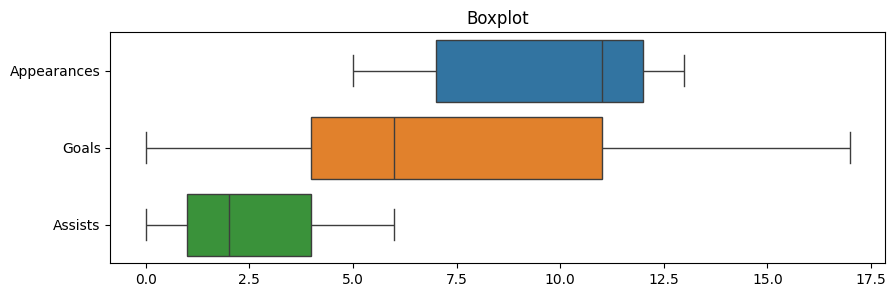

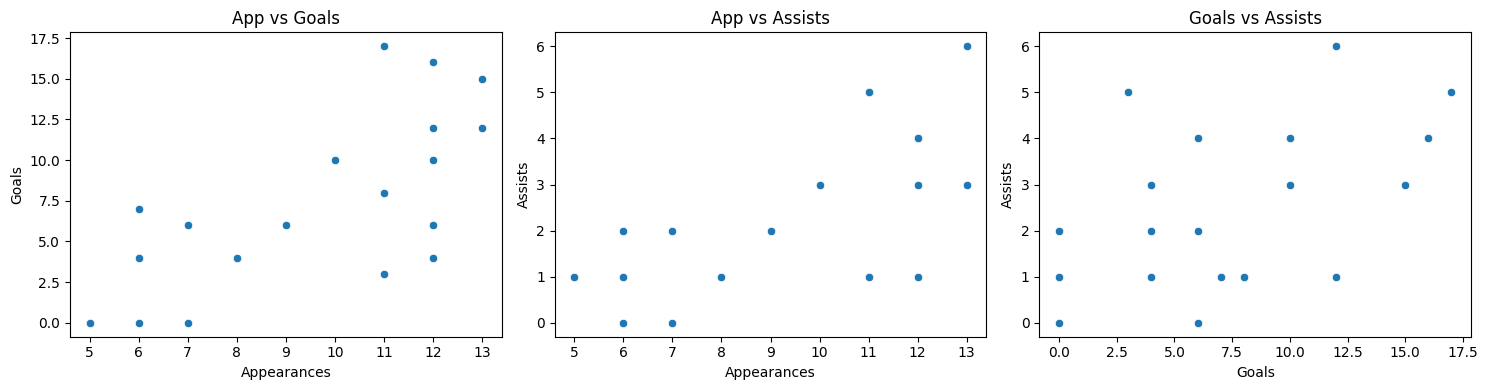

(e) Ma trận hiệp phương sai:
              Appearances      Goals   Assists
Appearances     7.467836  10.032164  3.371345
Goals          10.032164  28.023392  4.684211
Assists         3.371345   4.684211  3.152047


In [ ]:
import seaborn as sns

data_ronaldo = {
    'Appearances': [5, 7, 6, 11, 11, 12, 6, 12, 10, 12, 11, 12, 12, 13, 13, 9, 8, 6, 7],
    'Goals': [0, 0, 0, 3, 8, 4, 7, 6, 10, 12, 17, 10, 16, 12, 15, 6, 4, 4, 6],
    'Assists': [1, 2, 0, 5, 1, 3, 1, 4, 3, 1, 5, 4, 4, 6, 3, 2, 1, 2, 0]
}
df_cr7 = pd.DataFrame(data_ronaldo)

def calculate_stats(series):
    return pd.Series({
        'Mean': series.mean(),
        'Median': series.median(),
        'Variance': series.var(),
        'Std Dev': series.std(),
        'Q1': series.quantile(0.25),
        'Q3': series.quantile(0.75)
    })

stats_df = df_cr7.apply(calculate_stats)
print("(a & b) Thống kê mô tả:\n", stats_df)

plt.figure(figsize=(10, 3))
sns.boxplot(data=df_cr7, orient='h')
plt.title("Boxplot")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(ax=axes[0], data=df_cr7, x='Appearances', y='Goals').set_title("App vs Goals")
sns.scatterplot(ax=axes[1], data=df_cr7, x='Appearances', y='Assists').set_title("App vs Assists")
sns.scatterplot(ax=axes[2], data=df_cr7, x='Goals', y='Assists').set_title("Goals vs Assists")
plt.tight_layout()
plt.show()

print("(e) Ma trận hiệp phương sai:\n", df_cr7.cov())

## Bài 4: Kiểm định Chi-bình phương (Chi-Square Test)

**1. Đề bài:**
800 sinh viên thuộc ba ngành (Toán, Lịch sử, Khoa học máy tính) được hỏi liệu họ có thích chơi game hay không. Dữ liệu tổng hợp:

| Ngành học | Thích chơi | Không thích | Tổng |
|:---|:---:|:---:|:---:|
| **Toán** | 130 | 100 | 230 |
| **Lịch sử** | 35 | 165 | 200 |
| **Khoa học máy tính** | 280 | 90 | 370 |
| **Tổng** | 445 | 355 | 800 |

(a) Tính tần số kỳ vọng cho mỗi ô.  
(b) Sử dụng kiểm định $\chi^2$ để xác định liệu có mối liên hệ giữa ngành học và việc chơi game hay không.  

**2. Giải tay chi tiết:**
**Bước 1: Đặt giả thuyết:**
* $H_0$: Không có mối liên hệ giữa ngành học và sở thích chơi game (Hai biến này độc lập).
* $H_1$: Có mối liên hệ giữa ngành học và sở thích chơi game.

**(a) Tính tần số kỳ vọng ($E$):**
Áp dụng công thức $E = \frac{\text{Tổng Hàng} \times \text{Tổng Cột}}{\text{Tổng Toàn Bộ}}$
* Toán, Thích: $E_{11} = (230 \times 445) / 800 = \mathbf{127.9375}$
* Toán, Không: $E_{12} = (230 \times 355) / 800 = \mathbf{102.0625}$
* Lịch sử, Thích: $E_{21} = (200 \times 445) / 800 = \mathbf{111.25}$
* Lịch sử, Không: $E_{22} = (200 \times 355) / 800 = \mathbf{88.75}$
* KH Máy tính, Thích: $E_{31} = (370 \times 445) / 800 = \mathbf{205.8125}$
* KH Máy tính, Không: $E_{32} = (370 \times 355) / 800 = \mathbf{164.1875}$

**(b) Sử dụng kiểm định $\chi^2$:**
Ta tính giá trị kiểm định $\chi^2 = \sum \frac{(O - E)^2}{E}$ qua bảng chi tiết sau (với $O$ là tần số quan sát):

| Ô (Ngành, Sở thích) | $O$ (Quan sát) | $E$ (Kỳ vọng) | $O - E$ | $(O - E)^2$ | $\frac{(O - E)^2}{E}$ |
|:---|:---:|:---:|:---:|:---:|:---:|
| Toán, Thích | 130 | 127.9375 | 2.0625 | 4.2539 | 0.0332 |
| Toán, Không | 100 | 102.0625 | -2.0625 | 4.2539 | 0.0417 |
| Lịch sử, Thích | 35 | 111.2500 | -76.2500 | 5814.0625 | 52.2612 |
| Lịch sử, Không | 165 | 88.7500 | 76.2500 | 5814.0625 | 65.5099 |
| KHMT, Thích | 280 | 205.8125 | 74.1875 | 5503.7852 | 26.7418 |
| KHMT, Không | 90 | 164.1875 | -74.1875 | 5503.7852 | 33.5213 |

* **Tổng cộng giá trị kiểm định:** $\chi^2 = 0.0332 + 0.0417 + 52.2612 + 65.5099 + 26.7418 + 33.5213 = \mathbf{178.109}$
* **Bậc tự do:** $df = (\text{Số hàng} - 1) \times (\text{Số cột} - 1) = (3 - 1) \times (2 - 1) = \mathbf{2}$.
* **Tra bảng:** Với mức ý nghĩa $\alpha = 0.05$ và $df = 2$, giá trị $\chi^2$ tới hạn là $\mathbf{5.991}$.
* **Kết luận:** Vì $\chi^2 tính toán (178.109) > \chi^2 tới hạn (5.991)$, ta bác bỏ giả thuyết $H_0$.
=> **Kết luận cuối cùng:** Có bằng chứng thống kê mạnh mẽ cho thấy có mối liên hệ giữa ngành học và việc thích chơi game.

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, chi2

# Dữ liệu quan sát
observed = np.array([
    [130, 100],
    [35, 165],
    [280, 90]
])

chi2_stat, p_val, dof, expected = chi2_contingency(observed)

print("BẢNG TÍNH CHI TIẾT KIỂM ĐỊNH CHI-SQUARE:\n")
categories = ['Toán, Thích', 'Toán, Không', 'Lịch sử, Thích', 'Lịch sử, Không', 'KHMT, Thích', 'KHMT, Không']
obs_flat = observed.flatten()
exp_flat = expected.flatten()

# Lập dataframe cho các bước tính trung gian
df_calc = pd.DataFrame({
    'Ô': categories,
    'O': obs_flat,
    'E': exp_flat,
    'O - E': obs_flat - exp_flat,
    '(O - E)^2': (obs_flat - exp_flat)**2,
    '(O - E)^2 / E': ((obs_flat - exp_flat)**2) / exp_flat
})

print(df_calc.round(4).to_string(index=False))
print("-" * 60)
print(f"Tổng Chi-square (χ²) tính được: {df_calc['(O - E)^2 / E'].sum():.4f}")
print(f"Bậc tự do (df): {dof}")

alpha = 0.05
critical_value = chi2.ppf(1 - alpha, dof)
print(f"Giá trị tới hạn (với alpha = {alpha}): {critical_value:.4f}")
print(f"P-value: {p_val:.4e}")

print("\nKẾT LUẬN:")
if chi2_stat > critical_value:
    print("=> Chi-square > Giá trị tới hạn. Bác bỏ H0.")
    print("=> Có mối liên hệ ý nghĩa thống kê giữa ngành học và việc thích chơi game.")
else:
    print("=> Không đủ cơ sở bác bỏ H0.")

BẢNG TÍNH CHI TIẾT KIỂM ĐỊNH CHI-SQUARE:

             Ô   O        E    O - E  (O - E)^2  (O - E)^2 / E
   Toán, Thích 130 127.9375   2.0625     4.2539         0.0332
   Toán, Không 100 102.0625  -2.0625     4.2539         0.0417
Lịch sử, Thích  35 111.2500 -76.2500  5814.0625        52.2612
Lịch sử, Không 165  88.7500  76.2500  5814.0625        65.5106
   KHMT, Thích 280 205.8125  74.1875  5503.7852        26.7417
   KHMT, Không  90 164.1875 -74.1875  5503.7852        33.5213
------------------------------------------------------------
Tổng Chi-square (χ²) tính được: 178.1098
Bậc tự do (df): 2
Giá trị tới hạn (với alpha = 0.05): 5.9915
P-value: 2.1084e-39

KẾT LUẬN:
=> Chi-square > Giá trị tới hạn. Bác bỏ H0.
=> Có mối liên hệ ý nghĩa thống kê giữa ngành học và việc thích chơi game.
